# 09 — Confounder Analysis: Do Demographics Predict Pathology?

**Goal**: Determine whether donor-level confounders (SEX, AGE, RACE, Hardy Scale,
Ischemic Time) alone can predict tissue pathology categories, and whether adding
them to expression features improves performance.

Three model comparisons:
1. **Model A** — RF with confounders only (5 features, no feature selection)
2. **Model B** — RF with expression + confounders (AUC-based FS on expression, confounders always included)
3. **Performance delta** — AUC(B) − AUC(A)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import (
    load_cache, variance_filter,
    build_confounder_matrix, CONFOUNDER_COLS,
)
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_rf_model
from gtex_biomarkers.utils import run_all_confounder_models_parallel
from gtex_biomarkers.evaluation import (
    plot_roc_grid, plot_boxplot_grid, plot_roc_overlay,
    plot_comparison_scatter, plot_comparison_barplot,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## 9.1 — Build Confounder Matrix

Map donor-level demographics (SEX, AGE, RACE, DTHHRDY, TRISCHD) to each blood sample.
RACE codes 98/99 (unknown) are treated as NaN and median-imputed.

In [2]:
X_conf = build_confounder_matrix(df_age, blood_subjid)
print(f"Confounder matrix: {X_conf.shape[0]} samples × {X_conf.shape[1]} features")
print(f"Features: {list(X_conf.columns)}")
print()
display(X_conf.describe().round(2))
display(X_conf.head(10))

Confounder matrix: 803 samples × 5 features
Features: ['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD']



,SEX,AGE,RACE,DTHHRDY,TRISCHD
count,803.00,803.00,803.00,803.00,803.00
mean,1.33,52.81,2.85,1.12,491.91
std,0.47,13.03,0.40,1.40,410.54
min,1.00,20.00,1.00,0.00,0.00
25%,1.00,47.00,3.00,0.00,79.00
50%,1.00,55.00,3.00,0.00,447.00
75%,2.00,63.00,3.00,2.00,824.50
max,2.00,70.00,4.00,4.00,1641.00


,SEX,AGE,RACE,DTHHRDY,TRISCHD
GTEX-1117F-0005-SM-HL9SH,2,66,2.0,4.0,1200.0
GTEX-111CU-0005-SM-GJ3PH,1,57,3.0,0.0,43.0
GTEX-111FC-0006-SM-H65Z1,1,61,3.0,1.0,1028.0
GTEX-111YS-0006-SM-5NQBE,1,62,3.0,0.0,74.0
GTEX-1122O-0005-SM-5O99J,2,64,3.0,0.0,35.0
GTEX-1128S-0005-SM-5P9HI,2,66,3.0,2.0,816.0
GTEX-113IC-0006-SM-5NQ9C,1,66,2.0,0.0,94.0
GTEX-113JC-0006-SM-5O997,2,53,3.0,2.0,611.0
GTEX-117XS-0005-SM-5PNU6,1,64,3.0,2.0,848.0
GTEX-117YW-0005-SM-5NQ8Z,1,58,3.0,3.0,785.0


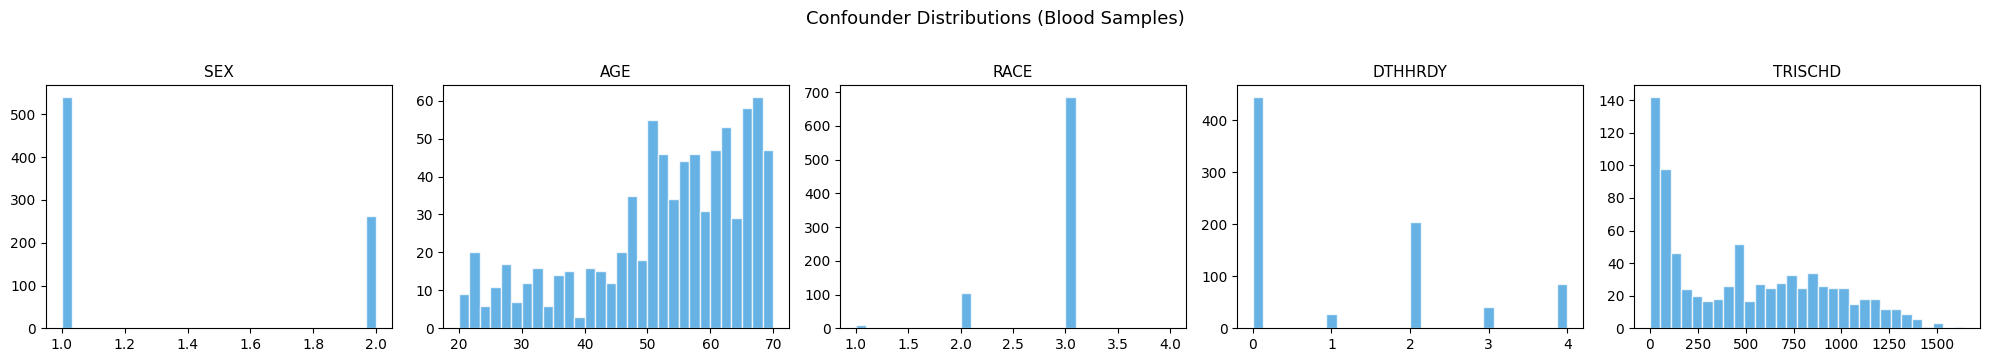

In [3]:
# Confounder distributions
fig, axes = plt.subplots(1, len(X_conf.columns), figsize=(4 * len(X_conf.columns), 3.5))
for ax, col in zip(axes, X_conf.columns):
    ax.hist(X_conf[col].dropna(), bins=30, color="#3498db", alpha=0.75, edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
fig.suptitle("Confounder Distributions (Blood Samples)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_distributions.pdf", bbox_inches="tight")
plt.show()

## 9.2 — Discover Tissue × Category Pairs

In [4]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total tissue × category pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total tissue × category pairs (≥ 50 samples): 53


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,137
1,Adipose - Visceral (Omentum),fibrosis,99
2,Artery - Aorta,atherosis,221
3,Artery - Aorta,atherosclerosis,101
4,Artery - Aorta,sclerotic,64
5,Artery - Aorta,calcification,53
6,Artery - Coronary,calcification,158
7,Artery - Coronary,atherosclerosis,153
8,Artery - Coronary,sclerotic,124
9,Artery - Coronary,atherosis,116


## 9.3 — Run Models (Parallelized by Tissue)

For each tissue × category pair, train two RF models in a single pass:
- **Model A**: Confounders only (SEX, AGE, RACE, DTHHRDY, TRISCHD) — no feature selection
- **Model B**: Variance-filtered expression (top 100 per fold) + all confounders

In [5]:
# Variance-filtered expression (top 20K genes) — same as notebook 07
X_wb_var, _ = variance_filter(X_wb)
print(f"Variance-filtered expression: {X_wb_var.shape[0]} samples × {X_wb_var.shape[1]} genes")

conf_results, conf_summary, comb_results, comb_summary = \
    run_all_confounder_models_parallel(
        pairs_df, df_meta_url, blood_subjid,
        X_wb_var, X_conf, make_rf_model
    )

print(f"Completed {len(conf_results)} confounder-only models")
print(f"Completed {len(comb_results)} expression+confounder models")

Variance-filtered expression: 803 samples × 20000 genes


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   6 out of  19 | elapsed:  6.5min remaining: 14.1min
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed:  6.6min remaining:  9.0min
[Parallel(n_jobs=-1)]: Done  10 out of  19 | elapsed:  7.9min remaining:  7.1min
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed:  8.3min remaining:  4.9min
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed:  8.4min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed:  9.5min remaining:  1.8min


Completed 53 confounder-only models
Completed 53 expression+confounder models


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed: 13.3min finished


## 9.4 — Summary Tables

In [6]:
# Save summaries
conf_summary.to_csv(Config.TABLES_DIR / "cv_results_confounder_only.csv", index=False)
comb_summary.to_csv(Config.TABLES_DIR / "cv_results_expr_plus_confounder.csv", index=False)

print("=== Model A: Confounder-Only RF ===")
display(conf_summary)
print()
print("=== Model B: Expression + Confounder RF ===")
display(comb_summary)

=== Model A: Confounder-Only RF ===


,tissue,category,mean_auc,std_auc,optimal_threshold
15,Breast - Mammary Tissue,gynecomastoid,0.868507,0.060523,0.296000
18,Breast - Mammary Tissue,atrophy,0.772285,0.039881,0.066000
16,Breast - Mammary Tissue,hyperplasia,0.754917,0.051751,0.326000
47,Spleen,congestion,0.720674,0.053307,0.982000
44,Pancreas,saponification,0.717051,0.024563,0.352000
48,Testis,spermatogenesis,0.650235,0.122915,0.952000
37,Lung,pneumonia,0.640349,0.074096,0.088000
10,Artery - Tibial,calcification,0.622944,0.052504,0.246000
19,Esophagus - Mucosa,esophagitis,0.619971,0.052468,0.247149
40,Muscle - Skeletal,atrophy,0.618750,0.092139,0.980000



=== Model B: Expression + Confounder RF ===


,tissue,category,mean_auc,std_auc,optimal_threshold
15,Breast - Mammary Tissue,gynecomastoid,0.875403,0.061324,0.360
18,Breast - Mammary Tissue,atrophy,0.844138,0.022329,0.056
47,Spleen,congestion,0.816906,0.026039,0.838
30,Liver,cirrhosis,0.794705,0.096380,0.150
16,Breast - Mammary Tissue,hyperplasia,0.751471,0.082132,0.362
37,Lung,pneumonia,0.741729,0.021265,0.128
44,Pancreas,saponification,0.731118,0.026903,0.456
48,Testis,spermatogenesis,0.719460,0.085770,0.916
40,Muscle - Skeletal,atrophy,0.691667,0.093541,0.844
28,Liver,congestion,0.683816,0.024515,0.620


## 9.5 — Performance Delta: Expression+Confounder vs Confounder-Only

Compute AUC(Model B) − AUC(Model A) for each tissue × category pair.
Positive delta = expression features add value beyond confounders alone.

In [7]:
# Build comparison table
comp = conf_summary[["tissue", "category", "mean_auc", "std_auc"]].merge(
    comb_summary[["tissue", "category", "mean_auc", "std_auc"]],
    on=["tissue", "category"],
    suffixes=("_conf", "_comb"),
)
comp["auc_delta"] = comp["mean_auc_comb"] - comp["mean_auc_conf"]
comp = comp.sort_values("auc_delta", ascending=False)
comp.to_csv(Config.TABLES_DIR / "cv_comparison_conf_vs_expr_conf.csv", index=False)

print(f"Models where expression adds value (delta > 0): {(comp['auc_delta'] > 0).sum()}/{len(comp)}")
print(f"Mean delta: {comp['auc_delta'].mean():.4f}")
print(f"Max delta:  {comp['auc_delta'].max():.4f}")
print()
display(comp)

Models where expression adds value (delta > 0): 39/53
Mean delta: 0.0452
Max delta:  0.2278



,tissue,category,mean_auc_conf,std_auc_conf,mean_auc_comb,std_auc_comb,auc_delta
21,Liver,cirrhosis,0.566866,0.064317,0.794705,0.096380,0.227839
50,Artery - Coronary,sclerotic,0.446685,0.055645,0.658171,0.081952,0.211486
51,Breast - Mammary Tissue,fibrosis,0.403861,0.043905,0.534164,0.096086,0.130304
52,Artery - Coronary,atherosclerosis,0.403631,0.072079,0.533720,0.035633,0.130089
47,Ovary,post_menopausal,0.460490,0.134921,0.585544,0.105363,0.125053
41,Artery - Aorta,sclerotic,0.492839,0.056612,0.614266,0.027635,0.121427
39,Adipose - Subcutaneous,fibrosis,0.506039,0.139330,0.625030,0.082752,0.118992
36,Liver,steatosis,0.508159,0.068574,0.625269,0.052573,0.117110
49,Lung,fibrosis,0.451357,0.068517,0.567472,0.025580,0.116115
28,Artery - Tibial,atherosis,0.534107,0.111438,0.640728,0.076269,0.106620


## 9.6 — Figures

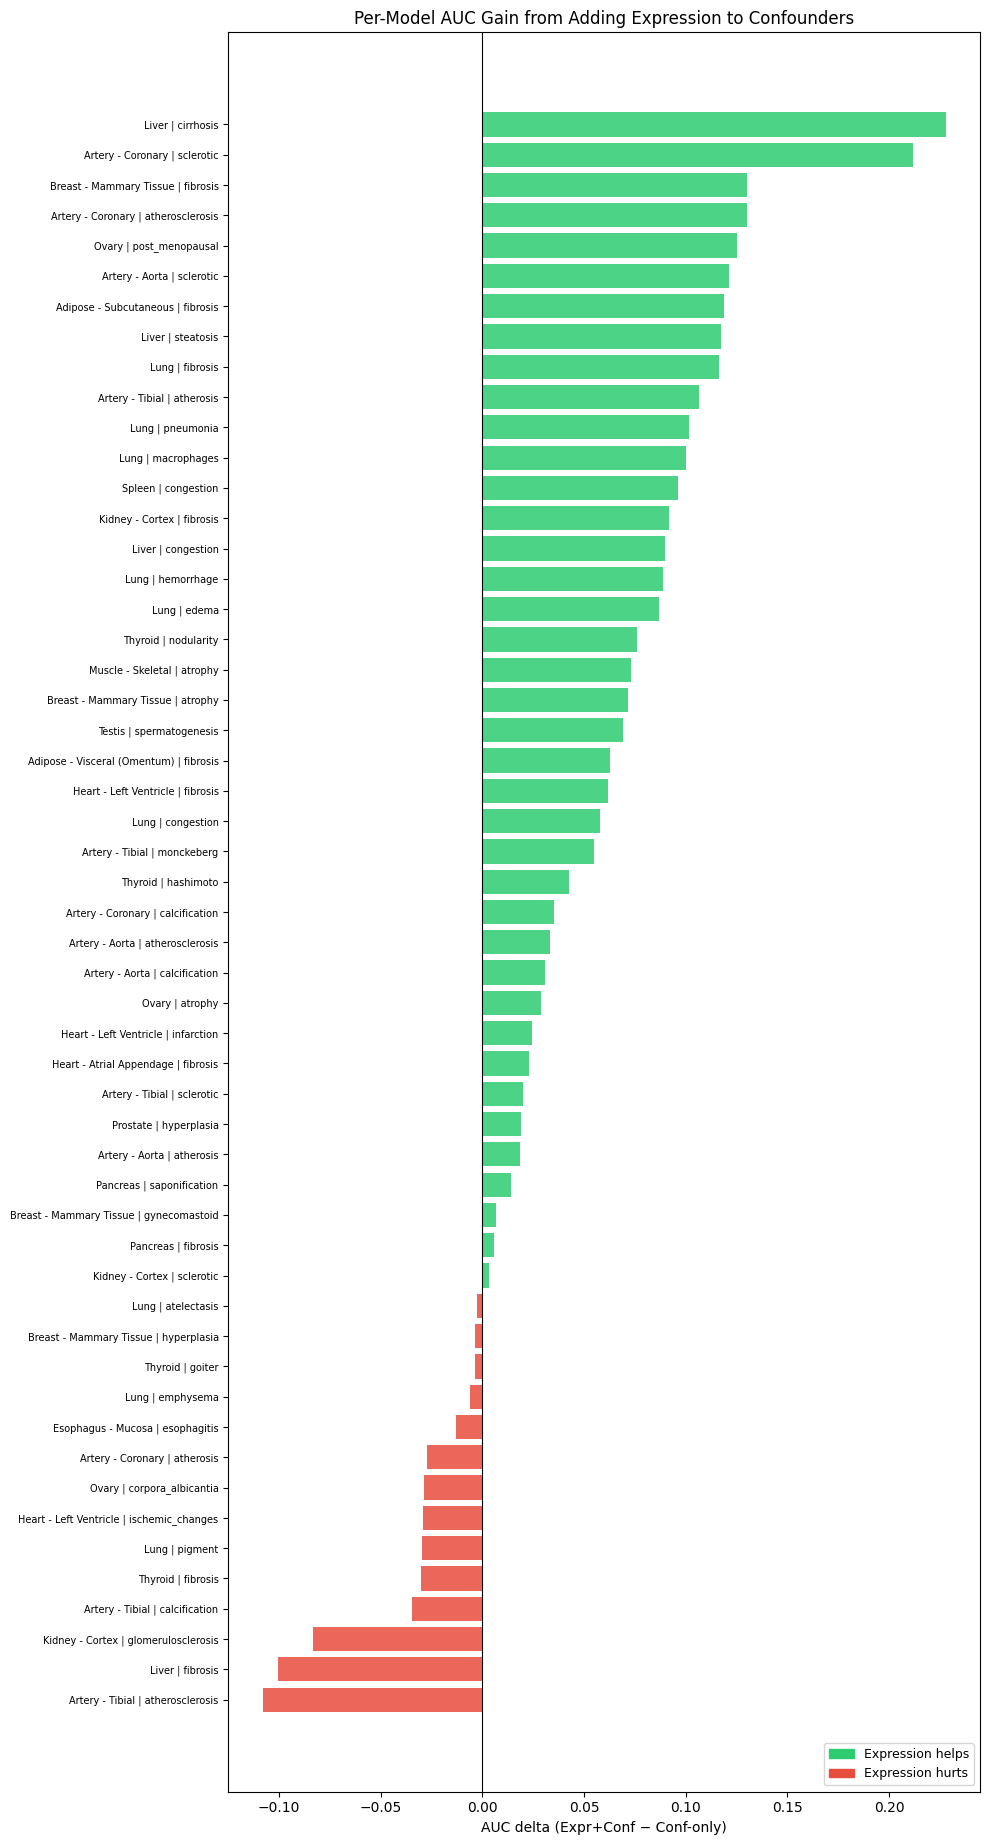

In [8]:
# 9.6a — AUC delta bar chart (combined vs confounder-only)
s = comp.sort_values("auc_delta", ascending=True).copy()
s["label"] = s["tissue"] + " | " + s["category"]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in s["auc_delta"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(s) * 0.35)))
ax.barh(range(len(s)), s["auc_delta"], color=colors, alpha=0.85)
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s["label"], fontsize=7)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("AUC delta (Expr+Conf − Conf-only)")
ax.set_title("Per-Model AUC Gain from Adding Expression to Confounders", fontsize=12)
ax.legend(
    handles=[Patch(color="#2ecc71", label="Expression helps"),
             Patch(color="#e74c3c", label="Expression hurts")],
    loc="lower right", fontsize=9,
)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_delta_barplot.pdf", bbox_inches="tight")
plt.show()

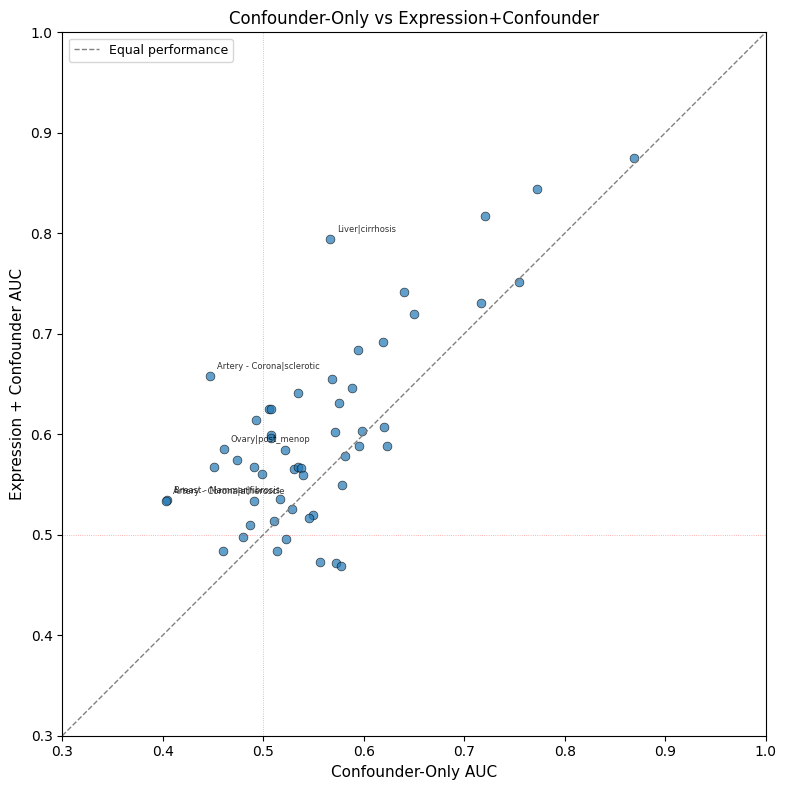

In [9]:
# 9.6b — Scatter: Confounder-only AUC (x) vs Combined AUC (y)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comp["mean_auc_conf"], comp["mean_auc_comb"],
           s=40, alpha=0.7, edgecolors="black", lw=0.5)
ax.plot([0.3, 1], [0.3, 1], ls="--", color="grey", lw=1, label="Equal performance")
ax.axhline(0.5, ls=":", color="red", lw=0.6, alpha=0.4)
ax.axvline(0.5, ls=":", color="red", lw=0.6, alpha=0.4)

# Label top 5 biggest gains
top5 = comp.nlargest(5, "auc_delta")
for _, row in top5.iterrows():
    ax.annotate(f"{row['tissue'][:15]}|{row['category'][:10]}",
                (row["mean_auc_conf"], row["mean_auc_comb"]),
                fontsize=6, alpha=0.8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Confounder-Only AUC", fontsize=11)
ax.set_ylabel("Expression + Confounder AUC", fontsize=11)
ax.set_title("Confounder-Only vs Expression+Confounder", fontsize=12)
ax.set_xlim(0.3, 1.0); ax.set_ylim(0.3, 1.0)
ax.set_aspect("equal"); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_scatter.pdf", bbox_inches="tight")
plt.show()

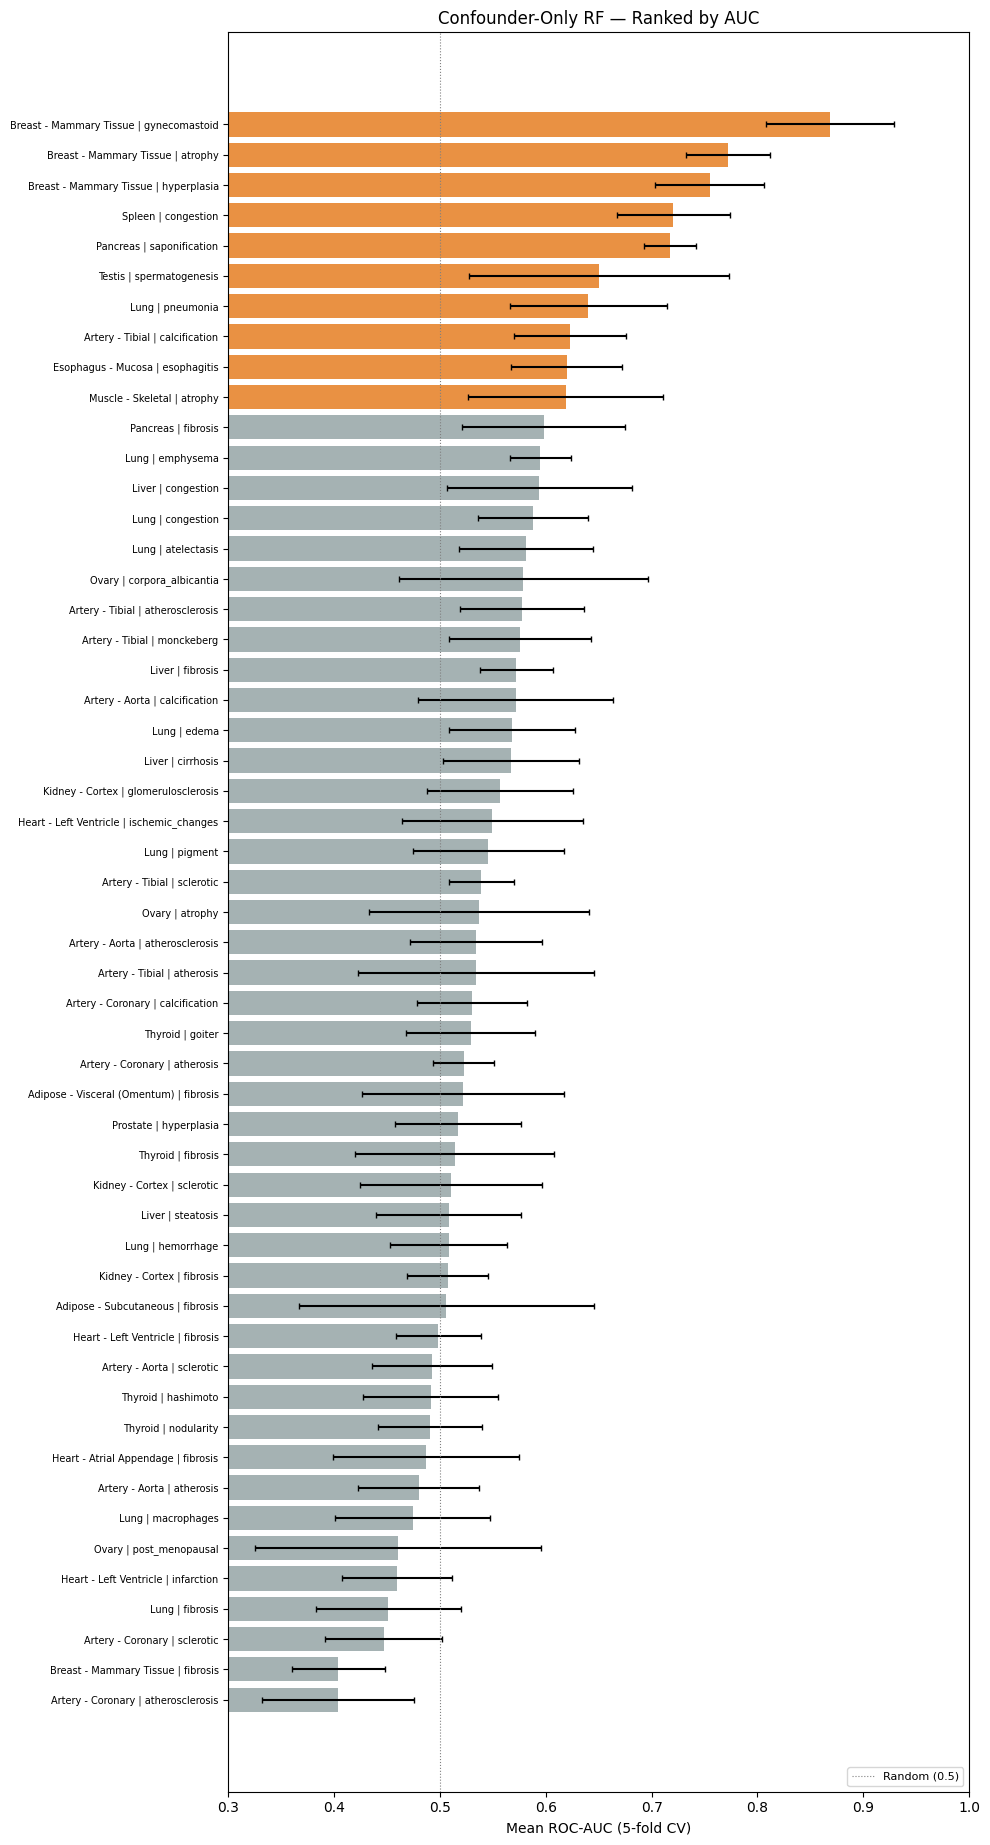

In [10]:
# 9.6c — Ranked bar chart: Confounder-only AUC for all models
s_conf = conf_summary.sort_values("mean_auc", ascending=True).copy()
s_conf["label"] = s_conf["tissue"] + " | " + s_conf["category"]
colors = ["#e67e22" if v >= 0.6 else "#95a5a6" for v in s_conf["mean_auc"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(s_conf) * 0.35)))
ax.barh(range(len(s_conf)), s_conf["mean_auc"], color=colors,
        xerr=s_conf["std_auc"], capsize=2, ecolor="black", alpha=0.85)
ax.set_yticks(range(len(s_conf)))
ax.set_yticklabels(s_conf["label"], fontsize=7)
ax.axvline(0.5, ls=":", color="grey", lw=0.8, label="Random (0.5)")
ax.set_xlabel("Mean ROC-AUC (5-fold CV)")
ax.set_title("Confounder-Only RF — Ranked by AUC", fontsize=12)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0.3, 1.0)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_only_ranked_barplot.pdf", bbox_inches="tight")
plt.show()

## 9.7 — Three-Way Comparison (Expression-Only vs Confounder-Only vs Combined)

Load expression-only RF results from notebook 07 output to see all three models side by side.

In [11]:
# Load expression-only RF summary (from notebook 07)
expr_only_path = Config.TABLES_DIR / "cv_results_all_tissue_rf.csv"
if expr_only_path.exists():
    expr_summary = pd.read_csv(expr_only_path)

    # Three-way merge
    three_way = (
        conf_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_conf"})
        .merge(
            expr_summary[["tissue", "category", "mean_auc"]]
            .rename(columns={"mean_auc": "auc_expr"}),
            on=["tissue", "category"], how="outer",
        )
        .merge(
            comb_summary[["tissue", "category", "mean_auc"]]
            .rename(columns={"mean_auc": "auc_comb"}),
            on=["tissue", "category"], how="outer",
        )
    )
    three_way["delta_expr_vs_conf"] = three_way["auc_expr"] - three_way["auc_conf"]
    three_way["delta_comb_vs_expr"] = three_way["auc_comb"] - three_way["auc_expr"]
    three_way = three_way.sort_values("auc_comb", ascending=False)
    three_way.to_csv(Config.TABLES_DIR / "cv_three_way_comparison.csv", index=False)

    print("Three-way comparison (sorted by combined AUC):")
    display(three_way)
else:
    print("Expression-only RF results not found. Run notebook 07 first.")
    three_way = None

Three-way comparison (sorted by combined AUC):


,tissue,category,auc_conf,auc_expr,auc_comb,delta_expr_vs_conf,delta_comb_vs_expr
17,Breast - Mammary Tissue,gynecomastoid,0.868507,0.881665,0.875403,0.013158,-0.006261
15,Breast - Mammary Tissue,atrophy,0.772285,0.841520,0.844138,0.069235,0.002619
47,Spleen,congestion,0.720674,0.826177,0.816906,0.105503,-0.009271
27,Liver,cirrhosis,0.566866,0.804298,0.794705,0.237432,-0.009593
18,Breast - Mammary Tissue,hyperplasia,0.754917,0.752899,0.751471,-0.002018,-0.001428
39,Lung,pneumonia,0.640349,0.736086,0.741729,0.095737,0.005643
45,Pancreas,saponification,0.717051,0.730258,0.731118,0.013207,0.000860
48,Testis,spermatogenesis,0.650235,0.711798,0.719460,0.061563,0.007663
40,Muscle - Skeletal,atrophy,0.618750,0.693750,0.691667,0.075000,-0.002083
28,Liver,congestion,0.593976,0.683426,0.683816,0.089450,0.000391


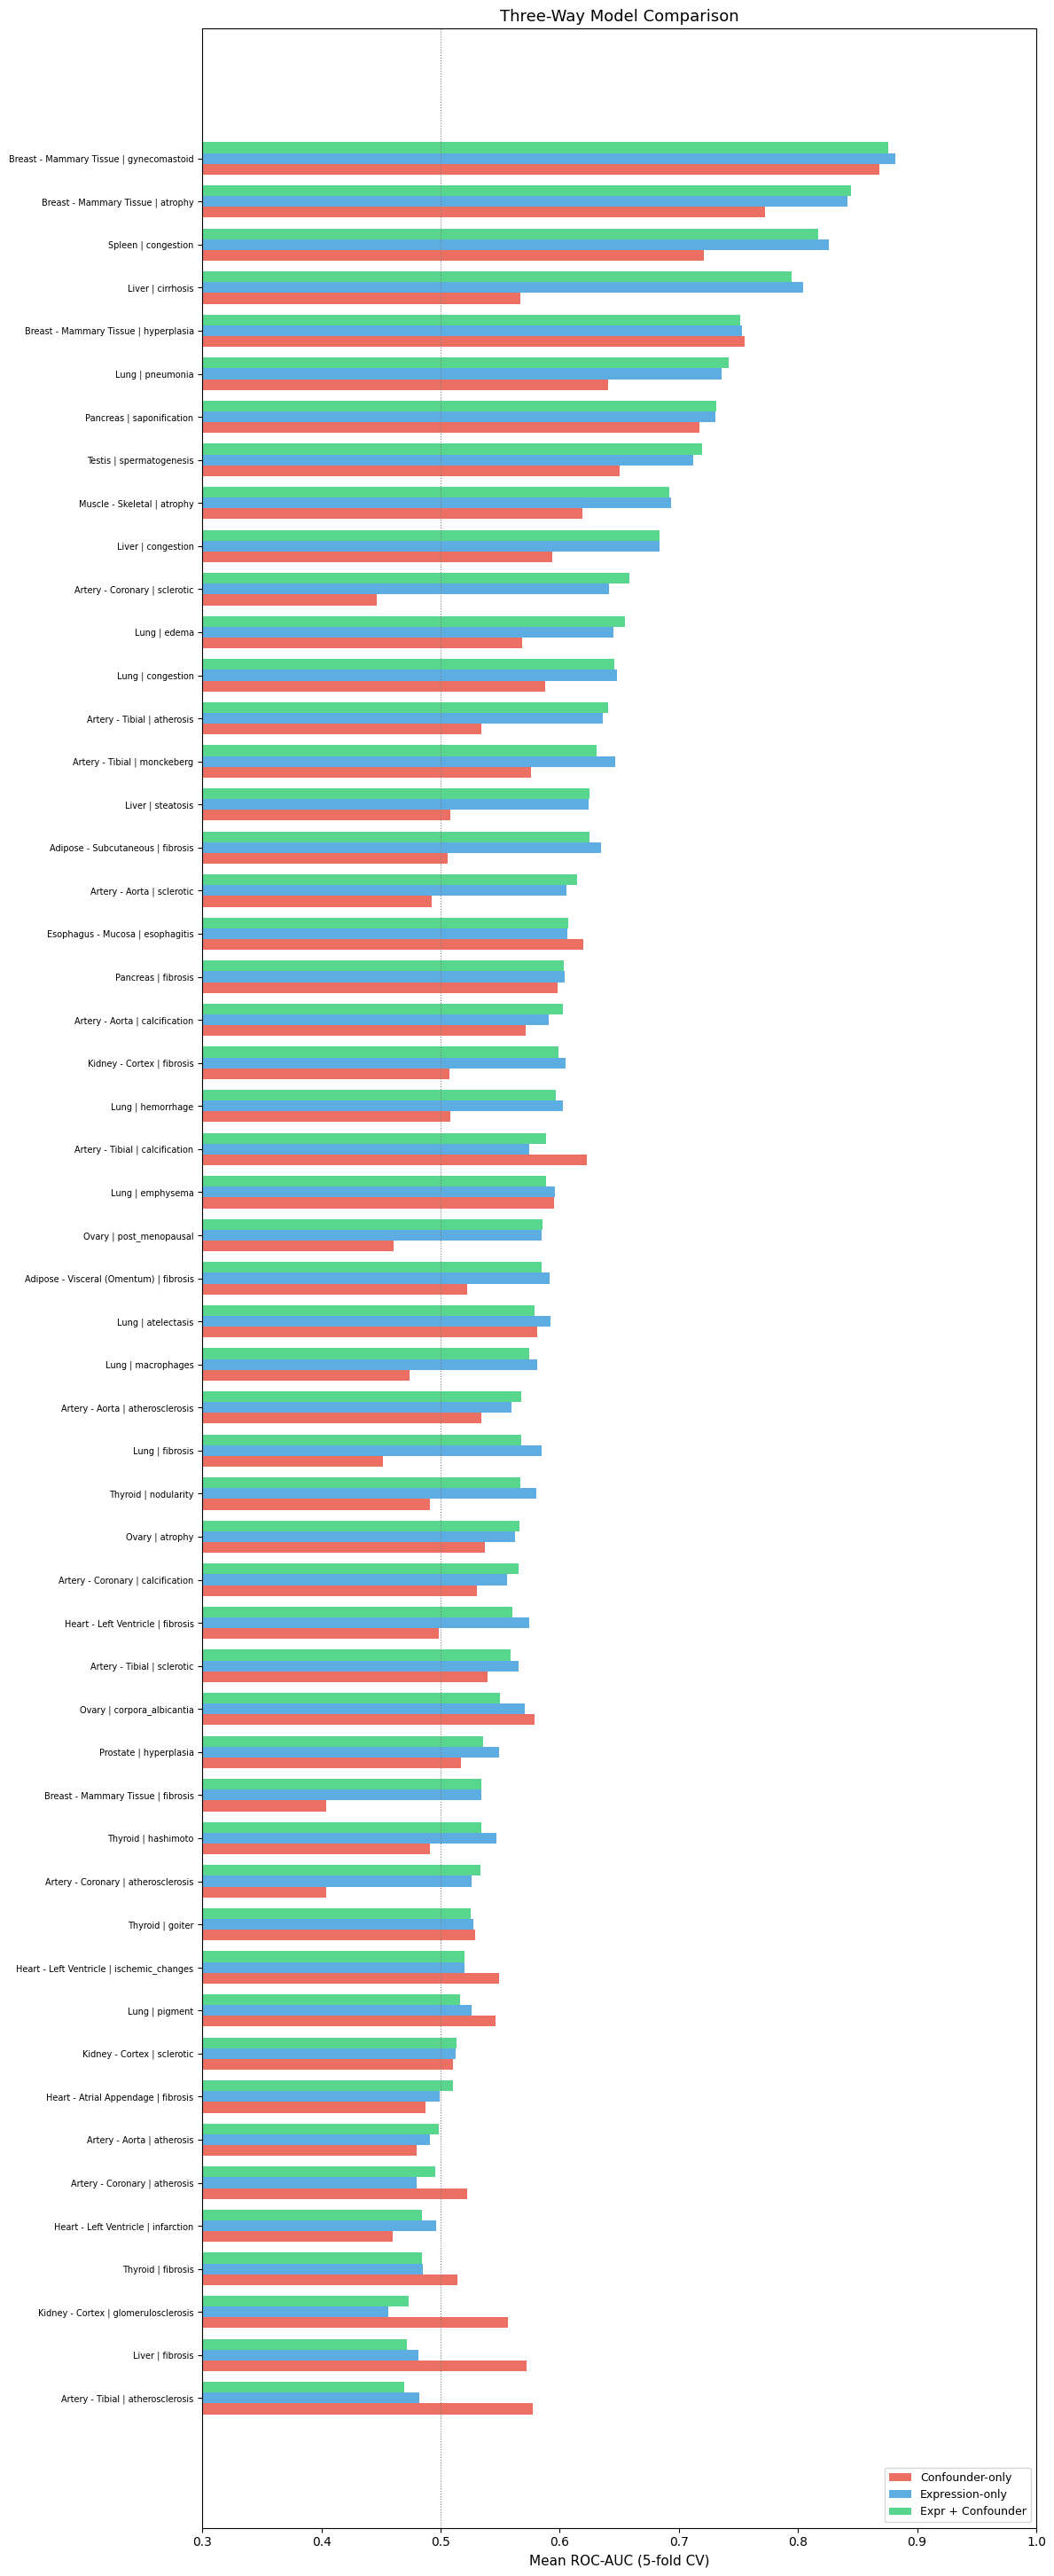

In [12]:
# 9.7b — Grouped bar chart: three models side by side
if three_way is not None:
    tw = three_way.dropna(subset=["auc_conf", "auc_expr", "auc_comb"]).copy()
    tw["label"] = tw["tissue"] + " | " + tw["category"]
    tw = tw.sort_values("auc_comb", ascending=True)

    y_pos = np.arange(len(tw))
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(12, max(7, len(tw) * 0.55)))
    ax.barh(y_pos - bar_h, tw["auc_conf"], bar_h, label="Confounder-only",
            color="#e74c3c", alpha=0.8)
    ax.barh(y_pos, tw["auc_expr"], bar_h, label="Expression-only",
            color="#3498db", alpha=0.8)
    ax.barh(y_pos + bar_h, tw["auc_comb"], bar_h, label="Expr + Confounder",
            color="#2ecc71", alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(tw["label"], fontsize=7)
    ax.axvline(0.5, ls=":", color="grey", lw=0.8)
    ax.set_xlabel("Mean ROC-AUC (5-fold CV)", fontsize=11)
    ax.set_title("Three-Way Model Comparison", fontsize=13)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0.3, 1.0)
    fig.tight_layout()
    fig.savefig(Config.FIGURES_DIR / "three_way_comparison_barplot.pdf", bbox_inches="tight")
    plt.show()

## 9.8 — ROC Curves for Confounder-Only Models

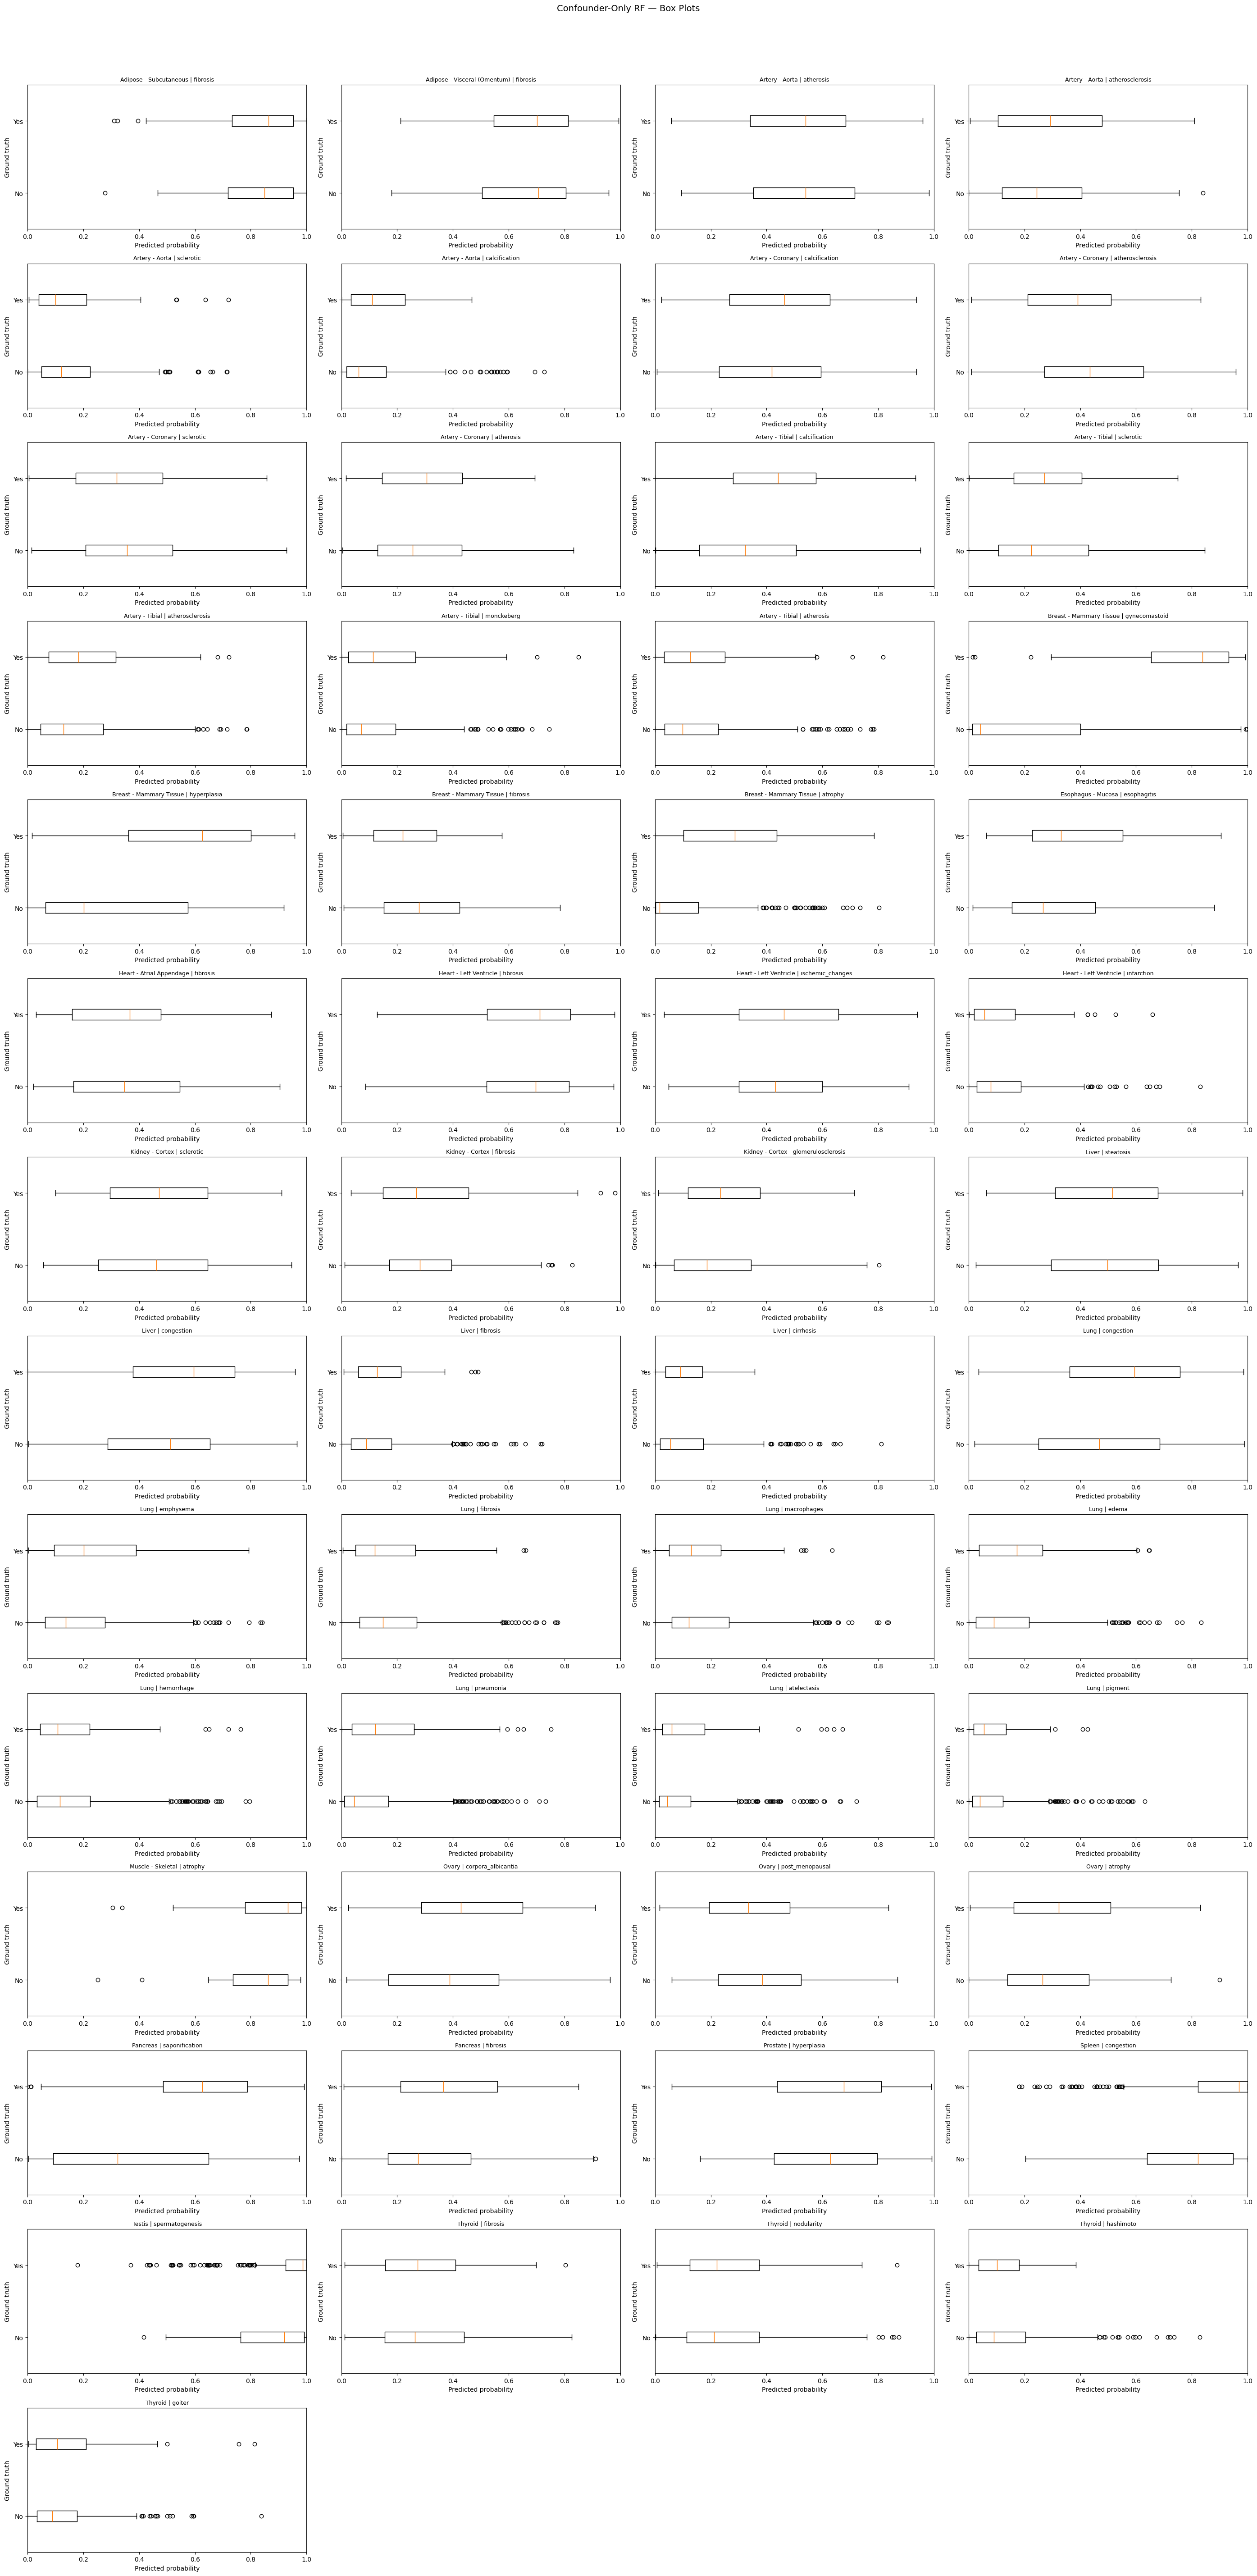

In [13]:
plot_roc_grid(conf_results,
             suptitle="Confounder-Only RF — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_confounder_only.pdf")

plot_boxplot_grid(conf_results,
                  suptitle="Confounder-Only RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_confounder_only.pdf")

## 9.9 — ROC Curves for Expression + Confounder Models

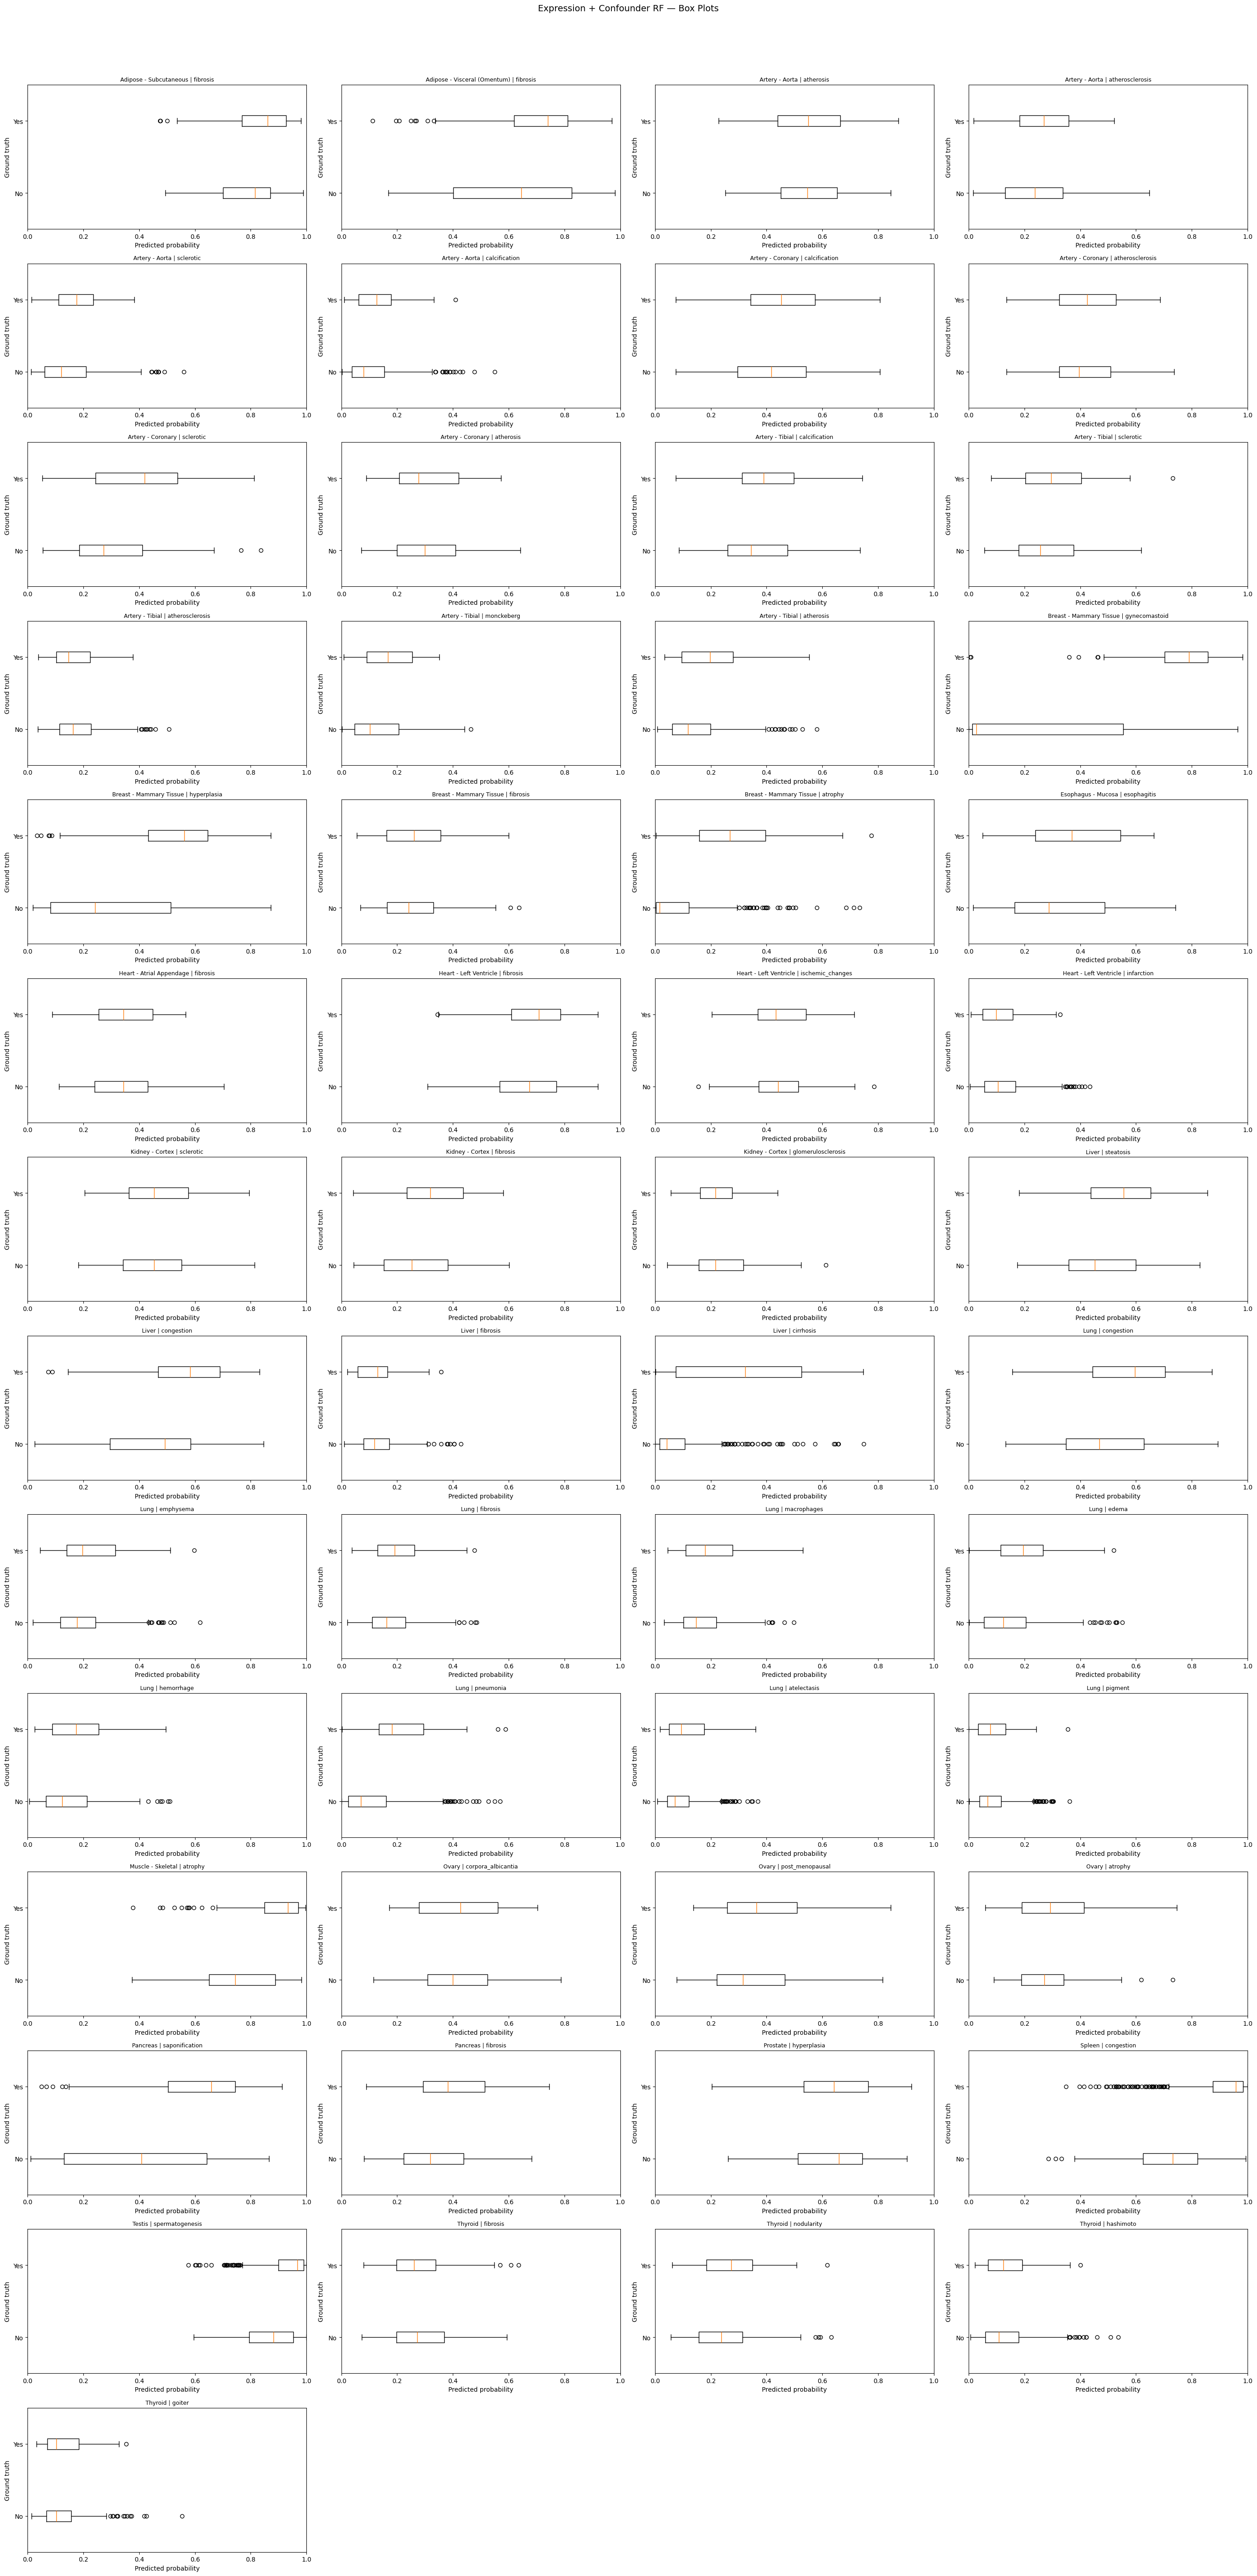

In [14]:
plot_roc_grid(comb_results,
             suptitle="Expression + Confounder RF — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_expr_plus_confounder.pdf")

plot_boxplot_grid(comb_results,
                  suptitle="Expression + Confounder RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_expr_plus_confounder.pdf")

## 9.10 — Individual Confounder Contributions

For each tissue × category pair, retrain the confounder-only RF on the full
labelled cohort and extract Gini feature importances (mean decrease in impurity).
This tells us how much each confounder contributes to each pathology prediction.

We then summarise:
1. **Heatmap** — per-confounder importance for every tissue × category pair
2. **Aggregated bar chart** — mean importance of each confounder averaged across all models
3. **Summary table** — which confounder dominates for each model

In [15]:
# 9.10a — Extract feature importances from confounder-only RF for each model
from sklearn.ensemble import RandomForestClassifier

importance_rows = []

for tag, res in conf_results.items():
    tissue = res["tissue"]
    category = res["category"]

    # Rebuild labels for this pair
    tissue_sub = df_meta_url[df_meta_url["Tissue"] == tissue].copy()
    tissue_sub["SUBJID"] = (
        tissue_sub["Tissue.Sample.ID"].astype(str)
        .str.split("-").str[:2].str.join("-")
    )
    known = tissue_sub[tissue_sub["Pathology.Categories"].notna()].copy()
    has_cat = known["Pathology.Categories"].str.contains(category, case=False).astype(int)
    donor_lab = has_cat.groupby(known["SUBJID"]).max()

    y_cat = blood_subjid.map(donor_lab)
    keep = y_cat.notna()
    X_conf_cat = X_conf.loc[keep].copy()
    y_cat = y_cat.loc[keep].astype(int)

    # Train RF on full data to get importances
    rf = RandomForestClassifier(
        n_estimators=Config.RF_N_ESTIMATORS,
        max_features=Config.RF_MAX_FEATURES,
        class_weight="balanced",
        random_state=Config.SEED,
        n_jobs=-1,
    )
    rf.fit(X_conf_cat, y_cat)

    row = {"tissue": tissue, "category": category, "tag": tag,
           "mean_auc": res["mean_auc"]}
    for feat, imp in zip(X_conf_cat.columns, rf.feature_importances_):
        row[feat] = imp
    importance_rows.append(row)

imp_df = pd.DataFrame(importance_rows)
conf_features = [c for c in X_conf.columns if c in imp_df.columns]

print(f"Extracted importances for {len(imp_df)} models × {len(conf_features)} confounders")
display(imp_df[["tag", "mean_auc"] + conf_features].round(4))

Extracted importances for 53 models × 5 confounders


,tag,mean_auc,SEX,AGE,RACE,DTHHRDY,TRISCHD
0,Adipose - Subcutaneous | fibrosis,0.5060,0.0582,0.3509,0.0406,0.1027,0.4476
1,Adipose - Visceral (Omentum) | fibrosis,0.5219,0.0478,0.3469,0.0425,0.0833,0.4796
2,Artery - Aorta | atherosis,0.4798,0.0343,0.3395,0.0386,0.0736,0.5140
3,Artery - Aorta | atherosclerosis,0.5344,0.0421,0.3495,0.0315,0.0820,0.4948
4,Artery - Aorta | sclerotic,0.4928,0.0401,0.3305,0.0372,0.0855,0.5066
5,Artery - Aorta | calcification,0.5715,0.0367,0.3376,0.0418,0.1067,0.4772
6,Artery - Coronary | calcification,0.5303,0.0336,0.3496,0.0352,0.0783,0.5033
7,Artery - Coronary | atherosclerosis,0.4036,0.0360,0.3454,0.0275,0.0699,0.5212
8,Artery - Coronary | sclerotic,0.4467,0.0388,0.3254,0.0308,0.0646,0.5405
9,Artery - Coronary | atherosis,0.5224,0.0387,0.3294,0.0358,0.0793,0.5168


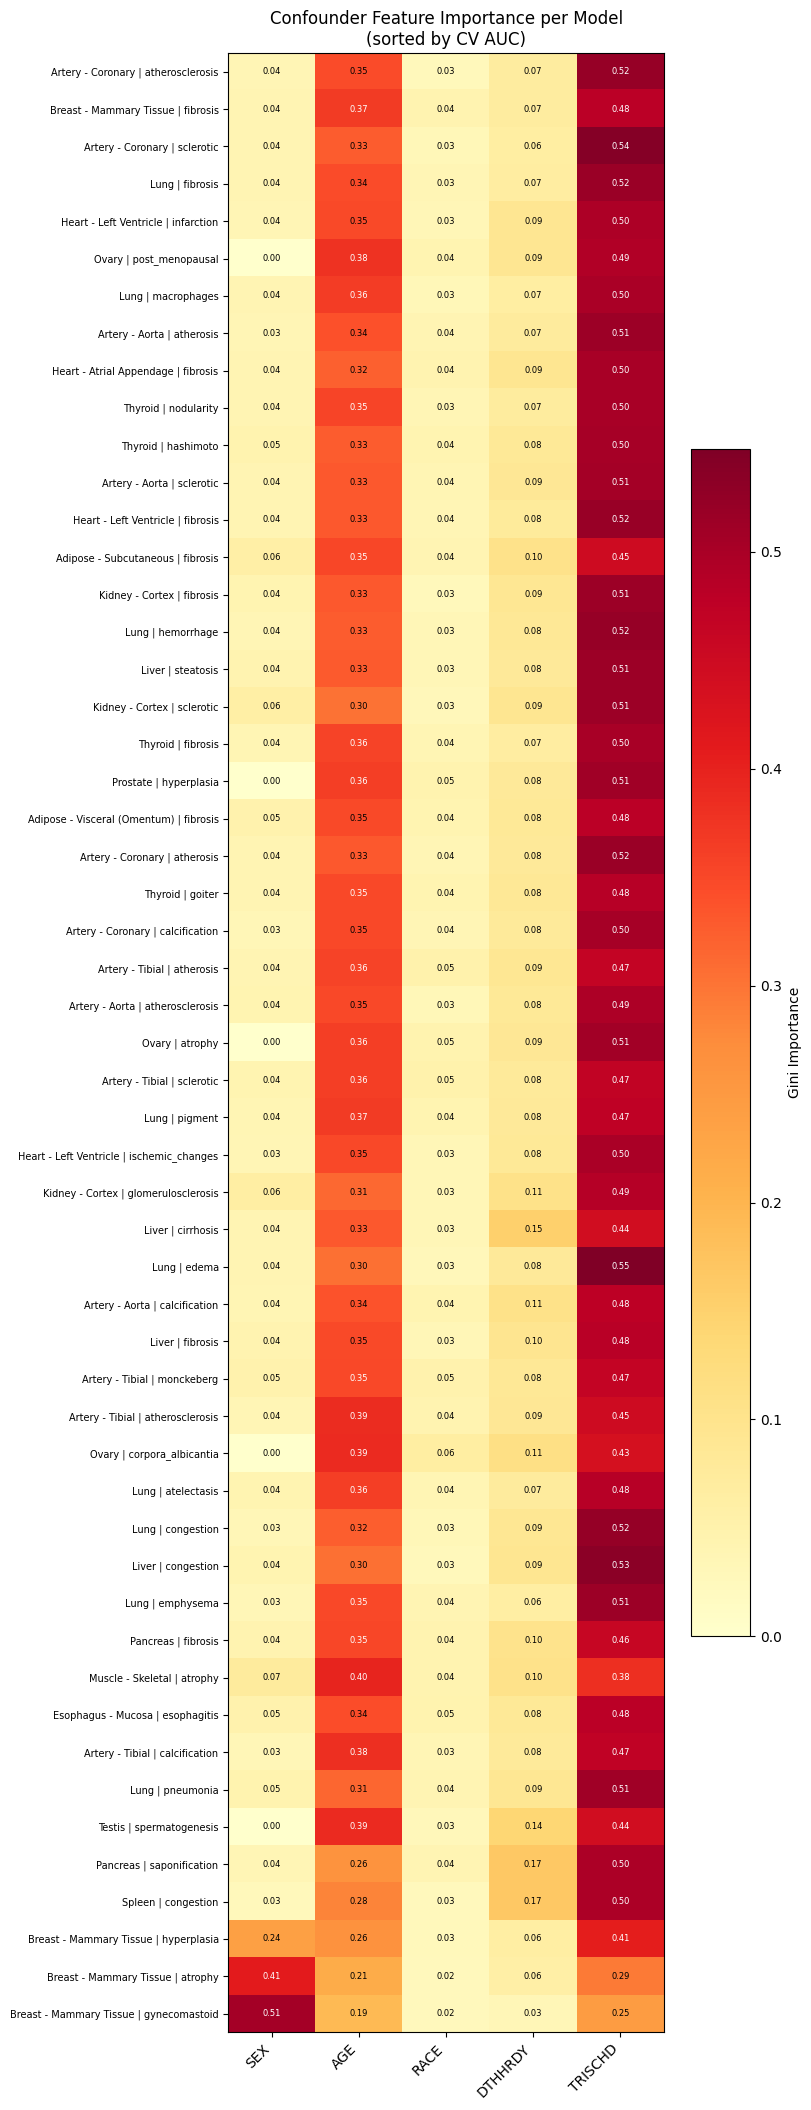

In [16]:
# 9.10b — Heatmap: per-confounder importance for each tissue × category pair
imp_df["label"] = imp_df["tissue"] + " | " + imp_df["category"]
imp_df_sorted = imp_df.sort_values("mean_auc", ascending=True)

imp_matrix = imp_df_sorted.set_index("label")[conf_features]

fig, ax = plt.subplots(figsize=(8, max(7, len(imp_matrix) * 0.4)))
im = ax.imshow(imp_matrix.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(conf_features)))
ax.set_xticklabels(conf_features, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(imp_matrix)))
ax.set_yticklabels(imp_matrix.index, fontsize=7)

# Annotate cells
for i in range(imp_matrix.shape[0]):
    for j in range(imp_matrix.shape[1]):
        val = imp_matrix.values[i, j]
        color = "white" if val > 0.35 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("Gini Importance", fontsize=10)
ax.set_title("Confounder Feature Importance per Model\n(sorted by CV AUC)", fontsize=12)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_importance_heatmap.pdf", bbox_inches="tight")
plt.show()

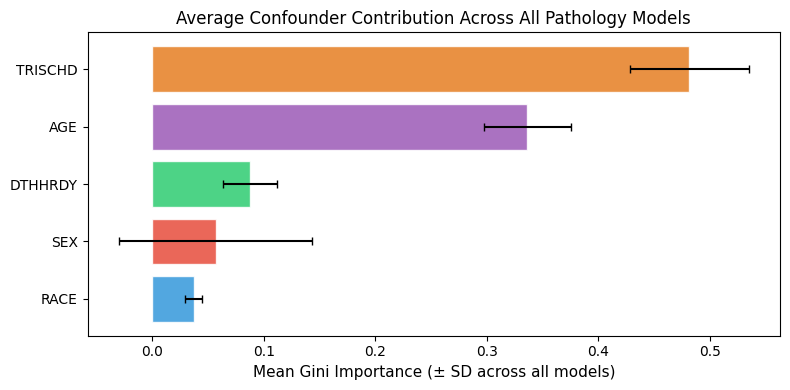


Mean ± SD importance across all models:
  TRISCHD     0.4817 ± 0.0531
  AGE         0.3366 ± 0.0389
  DTHHRDY     0.0876 ± 0.0241
  SEX         0.0569 ± 0.0864
  RACE        0.0372 ± 0.0078


In [19]:
# 9.10c — Aggregated bar chart: mean importance of each confounder across all models
mean_imp = imp_df[conf_features].mean().sort_values(ascending=True)
std_imp = imp_df[conf_features].std()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(mean_imp.index, mean_imp.values, xerr=std_imp[mean_imp.index].values,
               color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#e67e22"][:len(mean_imp)],
               capsize=3, alpha=0.85, edgecolor="white")
ax.set_xlabel("Mean Gini Importance (± SD across all models)", fontsize=11)
ax.set_title("Average Confounder Contribution Across All Pathology Models", fontsize=12)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_mean_importance_barplot.pdf", bbox_inches="tight")
plt.show()

print("\nMean ± SD importance across all models:")
for feat in mean_imp.index[::-1]:
    print(f"  {feat:10s}  {mean_imp[feat]:.4f} ± {std_imp[feat]:.4f}")

In [20]:
# 9.10d — Summary table: dominant confounder per model
imp_df["dominant_confounder"] = imp_df[conf_features].idxmax(axis=1)
imp_df["dominant_importance"] = imp_df[conf_features].max(axis=1)

summary_table = imp_df[["tag", "mean_auc", "dominant_confounder", "dominant_importance"]].copy()
summary_table = summary_table.sort_values("mean_auc", ascending=False)

print("Dominant confounder per model (sorted by AUC):")
display(summary_table.round(4))

print("\nHow often each confounder dominates:")
print(imp_df["dominant_confounder"].value_counts().to_string())

# Save full importance table
imp_df.to_csv(Config.TABLES_DIR / "confounder_feature_importances.csv", index=False)
print(f"\nSaved → {Config.TABLES_DIR / 'confounder_feature_importances.csv'}")

Dominant confounder per model (sorted by AUC):


,tag,mean_auc,dominant_confounder,dominant_importance
15,Breast - Mammary Tissue | gynecomastoid,0.8685,SEX,0.5054
18,Breast - Mammary Tissue | atrophy,0.7723,SEX,0.4087
16,Breast - Mammary Tissue | hyperplasia,0.7549,TRISCHD,0.4052
47,Spleen | congestion,0.7207,TRISCHD,0.4980
44,Pancreas | saponification,0.7171,TRISCHD,0.4976
48,Testis | spermatogenesis,0.6502,TRISCHD,0.4427
37,Lung | pneumonia,0.6403,TRISCHD,0.5100
10,Artery - Tibial | calcification,0.6229,TRISCHD,0.4718
19,Esophagus - Mucosa | esophagitis,0.6200,TRISCHD,0.4806
40,Muscle - Skeletal | atrophy,0.6188,AGE,0.3975



How often each confounder dominates:
dominant_confounder
TRISCHD    50
SEX         2
AGE         1

Saved → /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/tables/confounder_feature_importances.csv
